# Lab 4.1: Explaining Phishing Detectors

AI for Cybersecurity (D7084E / D7041E), Group 6
Kirill Silchenko (kirsil-5@student.ltu.se) and Stefanos Ntentopoulos (stente-5@student.ltu.se)

Parts A-D of the lab in order: train the detectors (supervised, semi-supervised, self-supervised),
explain them (glass boxes, SHAP, LIME), test the detector and the explanation (ablation, LIME
stability), and build a Belief Rule-Based expert system from the two most important features.
`random_state=42` throughout. Run from top to bottom; the dataset is `data/dataset_phishing.csv`
(or `dataset_phishing.csv` uploaded next to the notebook in Colab).

*Generated by `tools/assemble.py` from the notebooks in `parts/`. Do not edit this file by hand.*

<!-- STEP A0 -->
# Setup: lab steps A0–A3

Owner: T3. Every part notebook starts with `%run 00_setup.ipynb`; this notebook loads the data,
makes the 60 / 20 / 20 split and defines `report()`. The first line of every cell is a step marker
used by `tools/assemble.py`.

**A0. Libraries.** Colab has pandas, scikit-learn and matplotlib but not the two explanation
libraries. Locally everything comes from `requirements.txt`, so nothing is installed.

In [1]:
# STEP A0
# Install shap and lime only when they are missing (Colab). Locally they come from requirements.txt.
import importlib.util

if importlib.util.find_spec("shap") is None or importlib.util.find_spec("lime") is None:
    %pip install -q shap lime

# scipy 1.18 with scikit-learn 1.6.1 prints a harmless "Unknown solver options: iprint" warning
# every time a logistic regression is trained. It does not change any result, so we hide it.
import warnings
warnings.filterwarnings("ignore", message="Unknown solver options")

<!-- STEP A1 -->
## Step A1: Load the data

Web Page Phishing Detection (Hannousse & Yahiouche, 2021), CC BY 4.0: 11,430 URLs, half phishing
and half legitimate, 87 features; the label is in `status`. See `data/README.md`.

In [2]:
# STEP A1
import os
from pathlib import Path

import numpy as np
import pandas as pd

# The part notebooks live in parts/. Work from the repository root, so that
# data/ and results/ mean the same thing in every notebook.
if Path.cwd().name == "parts":
    os.chdir("..")

DATA = Path("data/dataset_phishing.csv")
if not DATA.exists():
    DATA = Path("dataset_phishing.csv")   # Colab: uploaded with the folder icon

# Every step saves its figures and tables here (TASKLIST section 2.5)
for folder in ["results/figures", "results/tables"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA)                     # the file you downloaded
print(df.shape)                            # should print (11430, 89)
print(df["status"].value_counts())         # 5715 phishing, 5715 legitimate

assert df.shape == (11430, 89), "unexpected dataset shape"
assert (df["status"].value_counts() == 5715).all(), "classes are not 5715 / 5715"
df.head()

(11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


<!-- STEP A2 -->
## Step A2: Prepare and split

The label becomes 1 = phishing, 0 = legitimate, and the raw `url` text is dropped. We split
60 / 20 / 20: **training** to learn, **validation** to choose settings, **test** only for the final
scores. `stratify` keeps 50% phishing in each part.

In [3]:
# STEP A2
from sklearn.model_selection import train_test_split

# The label: 1 = phishing, 0 = legitimate
y = (df["status"] == "phishing").astype(int)

# The features: everything except the raw URL text and the label.
# .astype(float) avoids type warnings later when we change values.
X = df.drop(columns=["url", "status"]).astype(float)

# 60% train, 20% validation, 20% test, same phishing share in each part
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(len(X_train), len(X_val), len(X_test))   # 6858 2286 2286

assert X.shape[1] == 87, "expected 87 features"
assert (len(X_train), len(X_val), len(X_test)) == (6858, 2286, 2286)
for name, part in [("train", y_train), ("validation", y_val), ("test", y_test)]:
    print(f"{name:10s} phishing share: {part.mean():.3f}")
    assert abs(part.mean() - 0.5) < 0.001, f"{name} is not 50% phishing"

6858 2286 2286
train      phishing share: 0.500
validation phishing share: 0.500
test       phishing share: 0.500


<!-- STEP A3 -->
## Step A3: A helper to score any model

Macro-F1, recall, ROC-AUC and FAR (false-alarm rate: share of legitimate URLs wrongly flagged).
Every model in the lab is scored with this function.

In [4]:
# STEP A3
from sklearn.metrics import (f1_score, recall_score, roc_auc_score,
                             confusion_matrix)

def report(model, X, y):
    """The four numbers we use for every model in this lab (3 decimals)."""
    pred = model.predict(X)
    prob = model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    scores = {
        "macro_F1": f1_score(y, pred, average="macro"),
        "recall":   recall_score(y, pred),     # share of phishing we caught
        "ROC_AUC":  roc_auc_score(y, prob),
        "FAR":      fp / (fp + tn),            # share of legit wrongly flagged
    }
    return {k: round(float(v), 3) for k, v in scores.items()}

<!-- STEP A4 -->
### 5.1 Supervised: all labels

## Step A4: Glass box 1: a small decision tree

We try depth 3 and 4 and keep the better one on the **validation** set (never on test). We read the
tree in step B1.

In [5]:
# STEP A4
from sklearn.tree import DecisionTreeClassifier, export_text

best_score, tree = -1, None
depth_scores = []                                  # both depths, for the report
for depth in [3, 4]:
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    scores = report(t, X_val, y_val)
    score = scores["macro_F1"]                     # choose on VALIDATION
    print("depth", depth, "validation macro-F1:", round(score, 3))
    depth_scores.append({"max_depth": depth, "leaves": t.get_n_leaves(), **scores})
    if score > best_score:
        best_score, tree = score, t
print("kept depth", tree.get_depth())

depth_scores = pd.DataFrame(depth_scores)
depth_scores.to_csv("results/tables/A4_tree_depth.csv", index=False)
depth_scores

depth 3 validation macro-F1: 0.913
depth 4 validation macro-F1: 0.925
kept depth 4


,max_depth,leaves,macro_F1,recall,ROC_AUC,FAR
0,3,8,0.913,0.904,0.948,0.079
1,4,16,0.925,0.920,0.954,0.070


<!-- STEP A5 -->
## Step A5: Glass box 2: logistic regression

One weight per feature. We scale the features first so the weights can be compared; the `Pipeline`
fits the scaler on training data only.

In [6]:
# STEP A5
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# The Pipeline fits the scaler on training data only. No leakage.
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg.fit(X_train, y_train)
print(report(logreg, X_val, y_val))

{'macro_F1': 0.938, 'recall': 0.933, 'ROC_AUC': 0.983, 'FAR': 0.056}


<!-- STEP A6 -->
## Step A6: The black box: a Random Forest

300 trees trained on all labels. This is the **upper line**: the best we can hope for when every URL
is labelled.

In [7]:
# STEP A6
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(report(rf, X_val, y_val))

{'macro_F1': 0.961, 'recall': 0.968, 'ROC_AUC': 0.993, 'FAR': 0.046}


<!-- STEP A7 -->
### 5.2 Semi-supervised: 5% labels plus unlabelled URLs

## Step A7: Hide 95% of the labels, and train the lower lines

We split the **training** set into 5% labelled and 95% unlabelled URLs, and train a forest and a
logistic regression on the 5% only. These are the **lower lines**: the unlabelled data only helped if a
model beats them. `y_hidden` is kept only to check the guesses in step A8: never train on it.

In [8]:
# STEP A7
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Pretend that only 5% of the training URLs have a label
X_lab, X_unlab, y_lab, y_hidden = train_test_split(
    X_train, y_train, train_size=0.05, stratify=y_train, random_state=42)
print(len(X_lab), "labelled,", len(X_unlab), "unlabelled")
# y_hidden = the labels we pretend we do not have. NEVER train on it:
# it is only used in step A8 to count how many pseudo-labels were right.

# The 5% split comes from the training set only: no validation or test URL is in it
assert (len(X_lab), len(X_unlab)) == (342, 6516)
assert set(X_lab.index) | set(X_unlab.index) == set(X_train.index)
assert not set(X_train.index) & (set(X_val.index) | set(X_test.index))
print("phishing share in the 5%:", round(y_lab.mean(), 3))

# Two lower lines: the same models, trained on the few labels only
rf_few = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_few.fit(X_lab, y_lab)
print("forest, 5% labels:", report(rf_few, X_val, y_val))

logreg_few = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(max_iter=1000)),
])
logreg_few.fit(X_lab, y_lab)
print("logreg, 5% labels:", report(logreg_few, X_val, y_val))

342 labelled, 6516 unlabelled
phishing share in the 5%: 0.5


forest, 5% labels: {'macro_F1': 0.938, 'recall': 0.946, 'ROC_AUC': 0.984, 'FAR': 0.069}
logreg, 5% labels: {'macro_F1': 0.912, 'recall': 0.915, 'ROC_AUC': 0.962, 'FAR': 0.092}


<!-- STEP A8 -->
## Step A8: Pseudo-labelling

As in Lab 2: the forest guesses the unlabelled URLs, keeps only the guesses it is very sure about
(`CUTOFF = 0.9`), and adds them as if they were labels. Three rounds, then the final model.
Each round we also count how many of the added guesses were right, by comparing them with
`y_hidden`. That is the only use of `y_hidden`: it never reaches `fit()`.

In [9]:
# STEP A8
# Semi-supervised: pseudo-labelling (the same idea as Lab 2)
X_now, y_now = X_lab.copy(), y_lab.copy()          # starts with the 5% real labels
pool = X_unlab.copy()                              # URLs without a label
rf_semi = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
CUTOFF = 0.9                                       # try 0.85 or 0.95 too

rounds = []                                        # one row per round, for the report
for rnd in [1, 2, 3]:
    rf_semi.fit(X_now, y_now)
    p = rf_semi.predict_proba(pool)[:, 1]
    sure = (p >= CUTOFF) | (1 - p >= CUTOFF)       # sure phishing OR sure legit
    guess = pd.Series((p[sure] >= 0.5).astype(int), index=pool.index[sure])
    X_now = pd.concat([X_now, pool[sure]])         # add them as labels
    y_now = pd.concat([y_now, guess])
    pool = pool[~sure]
    print(f"round {rnd}: added {sure.sum()} guesses,",
          f"{len(pool)} still unlabelled")

    # Check only: how many of this round's guesses were right? (y_hidden is not used to train)
    right = (guess == y_hidden.loc[guess.index])
    rounds.append({"round": rnd, "added": int(sure.sum()),
                   "added_phishing": int(guess.sum()),
                   "added_legitimate": int((guess == 0).sum()),
                   "correct": int(right.sum()),
                   "accuracy": round(float(right.mean()), 4) if len(guess) else float("nan"),
                   "still_unlabelled": len(pool)})

rf_semi.fit(X_now, y_now)                          # final model: labels + guesses
print("semi-supervised:", report(rf_semi, X_val, y_val))

rounds = pd.DataFrame(rounds)
all_guesses = y_now.iloc[len(y_lab):]              # every pseudo-label, without the 5% real ones
print(f"training rows for the final model: {len(X_now)} "
      f"({len(y_lab)} real labels + {len(all_guesses)} guesses)")
print("accuracy of all guesses:",
      round(float((all_guesses == y_hidden.loc[all_guesses.index]).mean()), 4))
rounds.to_csv("results/tables/A8_pseudo_label_rounds.csv", index=False)
rounds

round 1: added 2778 guesses, 3738 still unlabelled


round 2: added 1122 guesses, 2616 still unlabelled


round 3: added 365 guesses, 2251 still unlabelled


semi-supervised: {'macro_F1': 0.931, 'recall': 0.946, 'ROC_AUC': 0.982, 'FAR': 0.083}
training rows for the final model: 4607 (342 real labels + 4265 guesses)
accuracy of all guesses: 0.9885


,round,added,added_phishing,added_legitimate,correct,accuracy,still_unlabelled
0,1,2778,1280,1498,2762,0.9942,3738
1,2,1122,720,402,1105,0.9848,2616
2,3,365,213,152,349,0.9562,2251


<!-- STEP A9 -->
### 5.3 Self-supervised: learn from the URLs alone first

## Step A9: A fill-in-the-blanks network, then 5% labels

We hide 20% of the (scaled) values and train a small network to give back the complete row, without
labels. Its middle layer has 32 numbers per URL. A logistic regression then uses those 32 numbers and
the 5% labels. The fair comparison is `logreg_few` from step A7: the same model on the same 342 labels,
but on the original 87 features.

In [10]:
# STEP A9
# Self-supervised: learn from the URLs alone, no labels (like Lab 3)
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import FunctionTransformer

scaler = StandardScaler().fit(X_train)            # uses no labels
Z = scaler.transform(X_train)

# The made-up task: hide 20% of the clues and ask the network to fill them in
rng = np.random.default_rng(42)
hidden_part = rng.random(Z.shape) < 0.2
Z_masked = np.where(hidden_part, 0.0, Z)           # 0 = average value after scaling

ae = MLPRegressor(hidden_layer_sizes=(32,), max_iter=300, random_state=42)
ae.fit(Z_masked, Z)                                # input: with holes, target: complete
print("fill-in error:", round(ae.loss_, 3))

def encode(X):
    """The 32 numbers the network learned for each URL (its middle layer)."""
    h = scaler.transform(X) @ ae.coefs_[0] + ae.intercepts_[0]
    return np.maximum(h, 0)                        # same "relu" as inside the network

# Now use the 5% labels, but on the 32 learned numbers
self_sup = Pipeline([
    ("encode", FunctionTransformer(encode)),
    ("lr", LogisticRegression(max_iter=1000)),
])
self_sup.fit(X_lab, y_lab)
print("self-supervised:", report(self_sup, X_val, y_val))
print("logreg, 5% labels (the fair comparison):", report(logreg_few, X_val, y_val))

fill-in error: 0.167


self-supervised: {'macro_F1': 0.914, 'recall': 0.918, 'ROC_AUC': 0.966, 'FAR': 0.09}
logreg, 5% labels (the fair comparison): {'macro_F1': 0.912, 'recall': 0.915, 'ROC_AUC': 0.962, 'FAR': 0.092}


<!-- STEP A10 -->
### 5.4 Compare everything

## Step A10: All seven detectors on the same test set

This is the first and only time these models see the test set. The two comparisons that tell us whether
the unlabelled data helped: **semi-supervised vs forest (5%)** (both forests on the same 342 real
labels), and **self-supervised vs logreg (5%)** (both logistic regressions on the same 342 labels).
The forest with all labels is the upper line.

In [11]:
# STEP A10
models = {
    "tree":            tree,
    "logreg":          logreg,
    "forest (100%)":   rf,
    "forest (5%)":     rf_few,
    "logreg (5%)":     logreg_few,
    "semi-supervised": rf_semi,
    "self-supervised": self_sup,
}
results = pd.DataFrame({name: report(m, X_test, y_test)
                        for name, m in models.items()}).T
results.index.name = "model"
print(results.round(3))
results.to_csv("results/tables/A10_test_scores.csv")

# Did the unlabelled data help? Compare each model with its lower line (same model, same 5% labels)
def compare(new, lower_line):
    d = results.loc[new] - results.loc[lower_line]
    print(f"{new} vs {lower_line}: macro-F1 {d['macro_F1']:+.3f}, recall {d['recall']:+.3f}, "
          f"FAR {d['FAR']:+.3f}  (positive FAR = more false alarms)")

print()
compare("semi-supervised", "forest (5%)")
compare("self-supervised", "logreg (5%)")

# How far is each model from the upper line?
gap = (results["macro_F1"] - results.loc["forest (100%)", "macro_F1"]).round(3)
print("\nmacro-F1 minus the upper line, forest (100%):")
print(gap.sort_values(ascending=False).to_string())

                 macro_F1  recall  ROC_AUC    FAR
model                                            
tree                0.927   0.912    0.953  0.057
logreg              0.947   0.943    0.985  0.050
forest (100%)       0.965   0.968    0.994  0.038
forest (5%)         0.941   0.942    0.985  0.061
logreg (5%)         0.912   0.908    0.963  0.084
semi-supervised     0.934   0.940    0.980  0.071
self-supervised     0.918   0.922    0.970  0.087

semi-supervised vs forest (5%): macro-F1 -0.007, recall -0.002, FAR +0.010  (positive FAR = more false alarms)
self-supervised vs logreg (5%): macro-F1 +0.006, recall +0.014, FAR +0.003  (positive FAR = more false alarms)

macro-F1 minus the upper line, forest (100%):
model
forest (100%)      0.000
logreg            -0.018
forest (5%)       -0.024
semi-supervised   -0.031
tree              -0.038
self-supervised   -0.047
logreg (5%)       -0.053


<!-- STEP A10 -->
**What we see (test set, `random_state=42`)**

- **Did semi-supervised beat forest (5%)? No.** Macro-F1 0.934 against 0.941 (−0.007), recall 0.940
  against 0.942, and more false alarms (FAR 0.071 against 0.061). The pseudo-labels were mostly right
  (98.9% of 4,265, step A8), but their accuracy fell each round (99.4% → 95.6%), and the wrong ones
  cost more than the extra data gained. As the lab warns, a forest is already strong with 342 labels.
- **Did self-supervised beat logreg (5%)? Only slightly.** Macro-F1 0.918 against 0.912 (+0.006),
  recall 0.922 against 0.908 (+0.014), FAR almost the same (0.087 against 0.084). That is a small gain
  from one split and one seed, so we cannot say it is more than noise.
- **Distance to the upper line** (forest with all labels, macro-F1 0.965): forest (5%) −0.024,
  semi-supervised −0.031, self-supervised −0.047, logreg (5%) −0.053. With 5% of the labels, the plain
  forest stays closest; the unlabelled 95% did not close the gap.

<!-- STEP B1 -->
# 6. Part B: Explain the detectors

## Step B1: Read the glass boxes

The tree and the logistic regression need no SHAP or LIME: the model itself is the explanation.
In the tree, each `|---` line is a yes/no question and `class: 1` means phishing. In the logistic
regression, a positive weight pushes toward phishing (the features are scaled, so the weights can be
compared).

In [12]:
# STEP B1
# Glass box 1: the tree, printed as rules
tree_rules = export_text(tree, feature_names=list(X_train.columns))
print(tree_rules)
print("tree leaves:", tree.get_n_leaves())
with open("results/tables/B1_tree_rules.txt", "w") as f:
    f.write(tree_rules)

# Glass box 2: one weight per feature. Positive = pushes toward phishing.
w = pd.Series(logreg.named_steps["lr"].coef_[0], index=X_train.columns)
top10 = w.abs().sort_values(ascending=False).index[:10]
print(w[top10].round(3))
print("logreg weights with |w| > 0.01:", int((w.abs() > 0.01).sum()))
w[top10].round(3).rename("weight").to_csv("results/tables/B1_logreg_top10_weights.csv")

|--- google_index <= 0.50
|   |--- page_rank <= 0.50
|   |   |--- shortest_word_path <= 0.50
|   |   |   |--- nb_www <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_www >  0.50
|   |   |   |   |--- class: 0
|   |   |--- shortest_word_path >  0.50
|   |   |   |--- nb_hyphens <= 4.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyphens >  4.50
|   |   |   |   |--- class: 0
|   |--- page_rank >  0.50
|   |   |--- nb_qm <= 0.50
|   |   |   |--- phish_hints <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- phish_hints >  1.50
|   |   |   |   |--- class: 1
|   |   |--- nb_qm >  0.50
|   |   |   |--- nb_hyperlinks <= 32.50
|   |   |   |   |--- class: 1
|   |   |   |--- nb_hyperlinks >  32.50
|   |   |   |   |--- class: 0
|--- google_index >  0.50
|   |--- page_rank <= 2.50
|   |   |--- domain_in_brand <= 0.50
|   |   |   |--- ratio_extRedirection <= 1.58
|   |   |   |   |--- class: 1
|   |   |   |--- ratio_extRedirection >  1.58
|   |   |   |   |--- class: 0
|   |   |--- d

<!-- STEP B1 -->
**What we see**

- **The tree's first question, in plain English:** *"Has Google indexed this page?"*
  (`google_index <= 0.5` means yes, indexed). Every URL is first split on that. It makes sense to a
  security person: a phishing page lives for days and is rarely indexed. In the whole dataset, 84% of
  the non-indexed URLs are phishing and only 11% of the indexed ones. The second question on both
  branches is `page_rank`: how well-linked the site is.
- The tree has 16 leaves, so any decision can be read as at most 4 yes/no questions. Some leaves are
  less obvious, e.g. "not indexed, page rank above 2.5, more than 36 links and `web_traffic` at most
  4.5 → phishing", where `web_traffic` 0 means "no rank found".
- **Logistic regression:** 79 of the 87 weights have |w| > 0.01, so this "glass box" uses almost every
  feature, which makes it much harder to read than its top 10 suggests. Its strongest weight is
  `longest_words_raw` (+2.95, long words in the URL push toward phishing). `page_rank` (−1.70) and
  `google_index` (+1.54) point the same way as in the tree. Some signs are surprising, e.g. `nb_hyphens`
  is negative: a weight shows a feature's effect with all other features held fixed, and many features
  are correlated.

<!-- STEP B2 -->
## Step B2: SHAP for the supervised forest (global)

SHAP gives values for both classes, so we keep class 1 (phishing) with `sv[:, :, 1]`. The bar plot
shows the average push of each feature; the beeswarm shows one dot per URL (red = high value,
right = toward phishing). `shap_top` is also the ranking used to choose the BRB features in step D1.

(500, 87, 2)


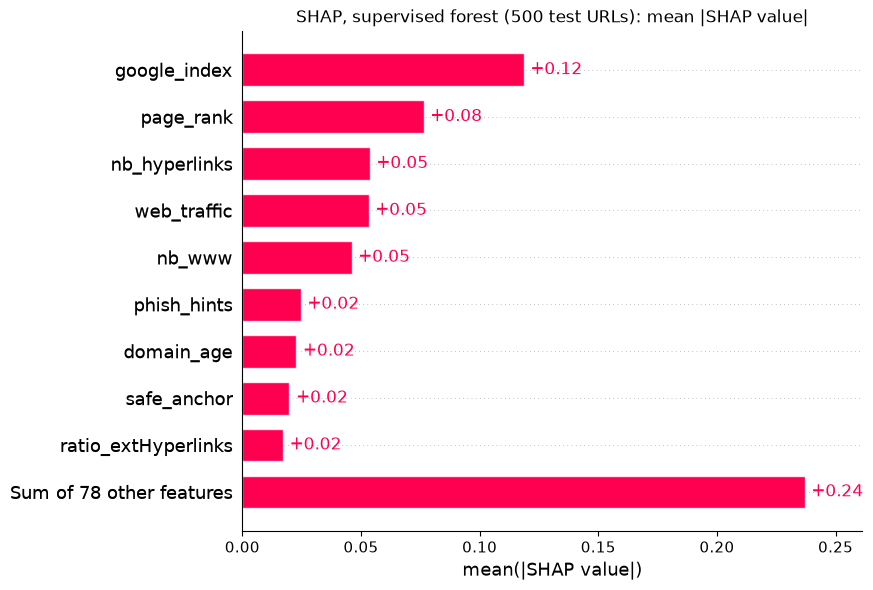

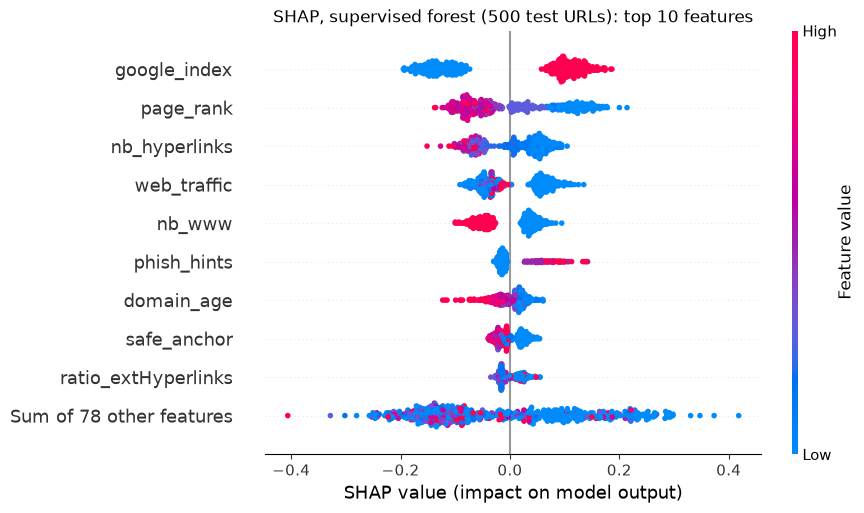

google_index            0.1186
page_rank               0.0764
nb_hyperlinks           0.0537
web_traffic             0.0532
nb_www                  0.0460
phish_hints             0.0246
domain_age              0.0227
safe_anchor             0.0199
ratio_extHyperlinks     0.0171
ratio_extRedirection    0.0142
dtype: float64


In [13]:
# STEP B2
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(rf)
sv = explainer(X_test.iloc[:500])         # 500 test URLs is plenty
print(sv.values.shape)                    # (500, 87, 2) = URLs, features, classes
assert sv.values.shape == (500, 87, 2)
sv1 = sv[:, :, 1]                         # keep class 1 = phishing

shap.plots.bar(sv1, max_display=10, show=False)        # average push of each feature
plt.title("SHAP, supervised forest (500 test URLs): mean |SHAP value|")
plt.savefig("results/figures/B2_shap_forest_bar.png", dpi=150, bbox_inches="tight")
plt.show()
shap.plots.beeswarm(sv1, max_display=10, show=False)   # one dot per URL
plt.title("SHAP, supervised forest (500 test URLs): top 10 features")
plt.savefig("results/figures/B2_shap_forest_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

shap_top = pd.Series(np.abs(sv1.values).mean(axis=0),
                     index=X_test.columns).sort_values(ascending=False)
print(shap_top.head(10).round(4))
shap_top.rename("mean_abs_shap").rename_axis("feature").to_csv("results/tables/B2_shap_top.csv")

<!-- STEP B2 -->
**What we see**

- **The top feature is `google_index`, and its red dots are on the right.** Red = high value = 1 =
  Google has **not** indexed the page, and right = toward phishing. In plain words: "not indexed by
  Google" is the forest's strongest single reason to call a URL phishing, and "indexed" (blue, left)
  its strongest reason to call it legitimate.
- The next features read the same way: a **low** `page_rank` (blue) and **few** links (`nb_hyperlinks`,
  blue) push toward phishing, and a **low** `web_traffic` pushes toward phishing too, because 0 means
  "no traffic rank found" (81% of those URLs are phishing). More phishing words (`phish_hints`, red)
  push toward phishing; a young domain (`domain_age`, blue) slightly so.
- Three of the top four features (`google_index`, `page_rank`, `web_traffic`) are **external lookups**.
  Step C1 tests what happens without them.

<!-- STEP B3 -->
## Step B3: SHAP for the semi- and self-supervised models

The semi-supervised model is a forest, so `TreeExplainer` works (exact and fast), on the same 500 test
URLs as the supervised forest in step B2. The self-supervised model is not a tree, so we use the
general `shap.Explainer` with 100 ordinary training URLs as the background, on 200 URLs (it is
slower).

(500, 87) (200, 87)


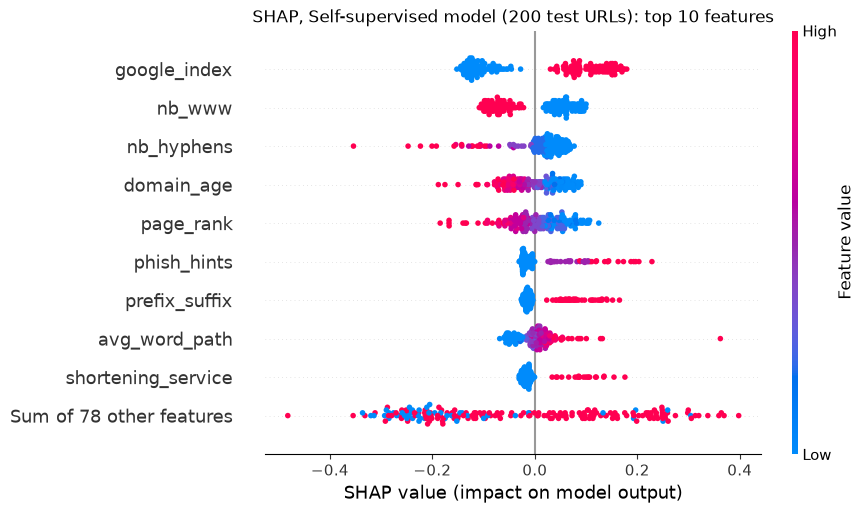

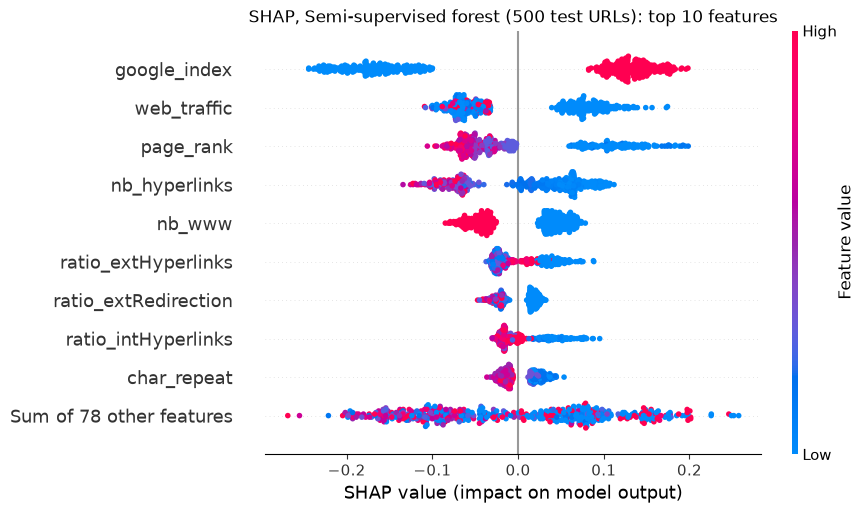

In [14]:
# STEP B3
import shap
import matplotlib.pyplot as plt

# Semi-supervised model: also a forest, so TreeExplainer works
sv_semi = shap.TreeExplainer(rf_semi)(X_test.iloc[:500])[:, :, 1]

# Self-supervised model: not a tree, so we use the general explainer.
# It works for any model but is slower, so we explain only 200 URLs.
def self_prob(a):
    a = pd.DataFrame(a, columns=X_train.columns)
    return self_sup.predict_proba(a)[:, 1]

background = X_train.sample(100, random_state=42)   # "ordinary" URLs
explainer_self = shap.Explainer(self_prob, background, seed=42)   # seed: its permutations are random
sv_self = explainer_self(X_test.iloc[:200], silent=True)   # silent: no progress bar
print(sv_semi.values.shape, sv_self.values.shape)    # (500, 87) (200, 87)
assert sv_semi.values.shape == (500, 87) and sv_self.values.shape == (200, 87)

for sv_model, name, title in [(sv_self, "self", "Self-supervised model (200 test URLs)"),
                              (sv_semi, "semi", "Semi-supervised forest (500 test URLs)")]:
    shap.plots.beeswarm(sv_model, max_display=10, show=False)
    plt.title(f"SHAP, {title}: top 10 features")
    plt.savefig(f"results/figures/B3_shap_{name}_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()

<!-- STEP B4 -->
## Step B4: Do the models look at the same clues?

The top 10 features of each model, side by side: the two glass boxes read directly (tree importance,
absolute logistic-regression weight) and the three SHAP rankings (mean absolute SHAP value).

In [15]:
# STEP B4
def top10(sv):
    s = pd.Series(np.abs(sv.values).mean(axis=0), index=X_test.columns)
    return s.sort_values(ascending=False).index[:10]

tree_top = pd.Series(tree.feature_importances_, index=X_train.columns)

lists = pd.DataFrame({
    "tree":        tree_top.sort_values(ascending=False).index[:10],
    "logreg":      w.abs().sort_values(ascending=False).index[:10],
    "SHAP forest": top10(sv1),
    "SHAP semi":   top10(sv_semi),
    "SHAP self":   top10(sv_self),
})
lists.index = range(1, 11)
lists.index.name = "rank"
print(lists.to_string())
lists.to_csv("results/tables/B4_top10_lists.csv")

# In how many of the 5 lists does each feature appear?
counts = pd.Series(lists.values.ravel()).value_counts()
print("\nfeatures in 3 or more lists:")
print(counts[counts >= 3].to_string())

# Does the self-supervised model look at other clues than the two forests?
forests = set(lists["SHAP forest"]) | set(lists["SHAP semi"])
print("\nshared top-10 features: forest & semi =",
      len(set(lists["SHAP forest"]) & set(lists["SHAP semi"])),
      "| self & forest =", len(set(lists["SHAP self"]) & set(lists["SHAP forest"])),
      "| self & semi =", len(set(lists["SHAP self"]) & set(lists["SHAP semi"])))
print("only in the self-supervised top 10:", sorted(set(lists["SHAP self"]) - forests))

                      tree             logreg           SHAP forest             SHAP semi           SHAP self
rank                                                                                                         
1             google_index  longest_words_raw          google_index          google_index        google_index
2                page_rank          page_rank             page_rank           web_traffic              nb_www
3            nb_hyperlinks        phish_hints         nb_hyperlinks             page_rank          nb_hyphens
4                   nb_www       google_index           web_traffic         nb_hyperlinks          domain_age
5                    nb_qm      avg_word_host                nb_www                nb_www           page_rank
6              web_traffic         nb_hyphens           phish_hints   ratio_extHyperlinks         phish_hints
7              phish_hints             nb_www            domain_age  ratio_extRedirection       prefix_suffix
8       sh

<!-- STEP B4 -->
**What we see**

- **In every one of the 5 lists:** `google_index`, `page_rank` and `nb_www`. **In 4 of 5:**
  `nb_hyperlinks` and `phish_hints`. So whichever way a model is built or explained, it leans on whether
  Google indexes the page, how well-linked the site is, how often "www" appears, how many links the page
  has and how many phishing words are in the URL. Two of these (`google_index`, `page_rank`) are
  external lookups, which step C1 removes.
- **The two forests look at almost the same clues** (8 of 10 shared). That is expected: the
  semi-supervised forest learned from pseudo-labels that a forest produced.
- **The self-supervised model partly looks elsewhere:** it shares only 5 features with the supervised
  forest and 3 with the semi-supervised one. Five of its top 10 appear in no forest list:
  `nb_hyphens`, `prefix_suffix`, `shortening_service`, `avg_word_path`, `domain_in_title`, almost all
  taken from the URL text. It still agrees on the strongest clue: `google_index` is first in both
  SHAP forest lists and in its own.
- **One surprise in its beeswarm (figure `B3_shap_self_beeswarm.png`):** many hyphens push toward
  *legitimate*, although hyphens are usually a phishing sign. A linear model on 32 learned numbers can
  pick up such indirect patterns; it is a reason not to trust this model's explanation blindly.
- **The logistic regression is the odd one out** among the supervised models: its top weight is
  `longest_words_raw`, and its list is mostly URL-text features, because a weight reflects one feature
  with the others held fixed, not how much the feature matters on its own.

<!-- STEP B5 -->
## Step B5: Pick three URLs to explain

The phishing URL the forest is most sure about, the legitimate URL it is most sure about, and its most
confident mistake (mistakes teach the most). The numbers `i_phish`, `i_legit` and `i_wrong` are
**positions** in `X_test` (use `.iloc`).

In [16]:
# STEP B5
prob = rf.predict_proba(X_test)[:, 1]       # P(phishing) for every test URL
pred = (prob >= 0.5).astype(int)
yt = y_test.values

# the surest correct phishing alert
caught = np.where((yt == 1) & (pred == 1))[0]
i_phish = caught[np.argmax(prob[caught])]

# the surest correct legitimate URL
ok_legit = np.where((yt == 0) & (pred == 0))[0]
i_legit = ok_legit[np.argmin(prob[ok_legit])]

# the most confident mistake (or the least sure URL if there is no mistake)
wrong = np.where(yt != pred)[0]
if len(wrong) > 0:
    i_wrong = wrong[np.argmax(np.abs(prob[wrong] - 0.5))]
else:
    i_wrong = np.argmin(np.abs(prob - 0.5))

three = [("phishing", i_phish), ("legitimate", i_legit), ("wrong", i_wrong)]
for name, i in three:
    print(f"{name:10s} row {i}: P(phishing) = {prob[i]:.3f},",
          f"true label = {yt[i]}")

# The raw URL text of each, so we can say what the mistake looked like
three_urls = pd.DataFrame([{"name": name, "position": int(i), "P_phishing": round(float(prob[i]), 3),
                            "true_label": int(yt[i]), "url": df.loc[X_test.index[i], "url"]}
                           for name, i in three])
print("test mistakes in total:", len(wrong), "of", len(yt))
three_urls.to_csv("results/tables/B5_three_urls.csv", index=False)
three_urls

phishing   row 34: P(phishing) = 1.000, true label = 1
legitimate row 10: P(phishing) = 0.000, true label = 0
wrong      row 1257: P(phishing) = 0.950, true label = 0
test mistakes in total: 80 of 2286


,name,position,P_phishing,true_label,url
0,phishing,34,1.00,1,https://support-appleld.com.secureupdate.duila...
1,legitimate,10,0.00,0,http://en.academic.ru/dic.nsf/enwiki/100376
2,wrong,1257,0.95,0,http://graphicsfairy.blogspot.ru/


<!-- STEP B5 -->
**What we see**

The forest makes 80 mistakes on the 2,286 test URLs. The three URLs:

- **Phishing** (row 34, P = 1.000): `https://support-appleld.com.secureupdate.duilawyeryork.com/ap/...`
  — a fake Apple support address ("appleld" with a lower-case L) on someone else's domain.
- **Legitimate** (row 10, P = 0.000): `http://en.academic.ru/dic.nsf/enwiki/100376`.
- **Most confident mistake** (row 1257, P = 0.950, truly legitimate):
  `http://graphicsfairy.blogspot.ru/` — a real blog on Google's free Blogspot service.

<!-- STEP B6 -->
## Step B6: Local explanations with SHAP and LIME

For each of the three URLs: a SHAP waterfall (from the base value to this URL's score, feature by
feature) and a LIME chart (a straight line fitted around this URL). Red/right (SHAP) and positive
weights (LIME) push toward phishing. A LIME fit score below 0.5 means the line copies the model badly:
do not trust that explanation much.

phishing

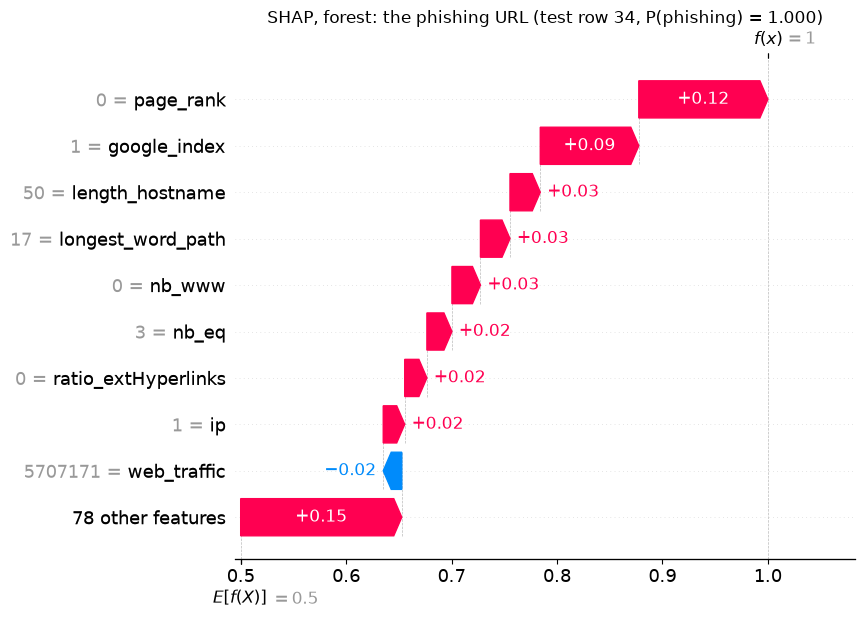

legitimate


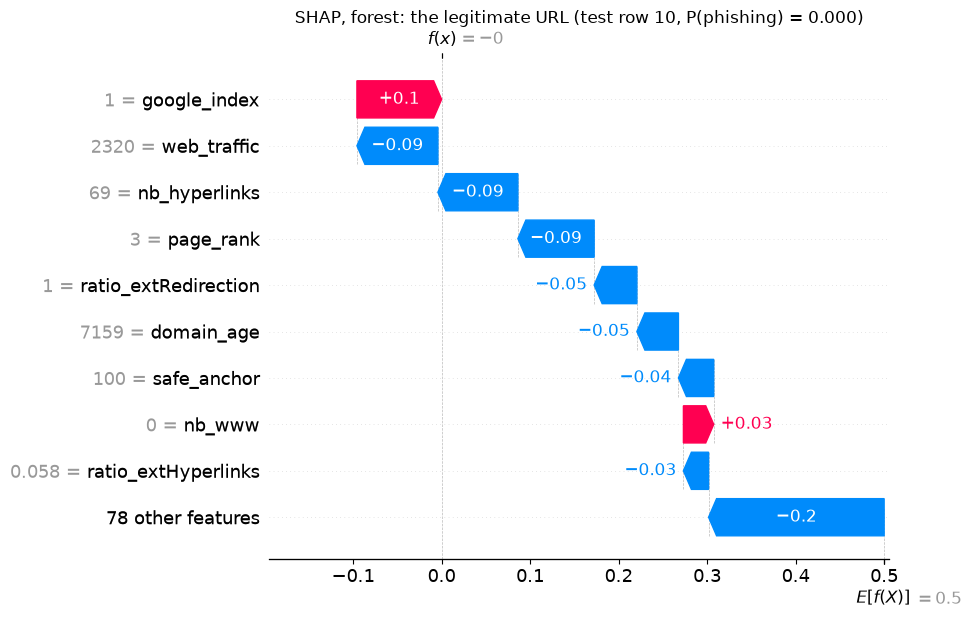

wrong


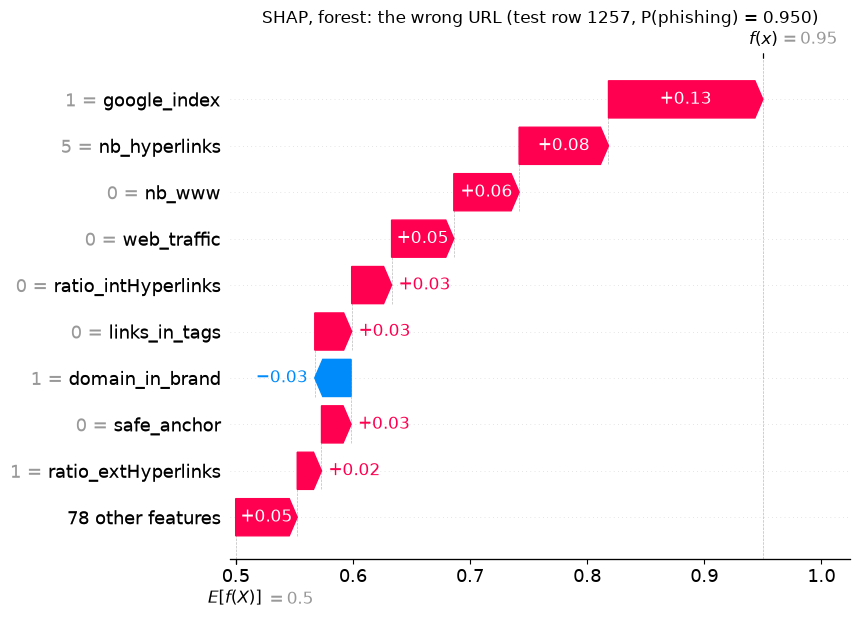

In [17]:
# STEP B6
for name, i in three:
    one = explainer(X_test.iloc[[i]])[:, :, 1]     # this URL, class phishing
    print(name)
    shap.plots.waterfall(one[0], max_display=10, show=False)
    plt.title(f"SHAP, forest: the {name} URL (test row {i}, P(phishing) = {prob[i]:.3f})")
    plt.savefig(f"results/figures/B6_shap_waterfall_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

phishing - fit score: 0.63 
   0.00 < google_index <= 1.00  +0.188
   page_rank <= 1.00            +0.161
   nb_www <= 0.00               +0.085
   phish_hints <= 0.00          -0.078
   longest_word_path > 11.00    +0.044
   right_clic <= 0.00           -0.026
   path_extension <= 0.00       +0.020
   punycode <= 0.00             -0.016


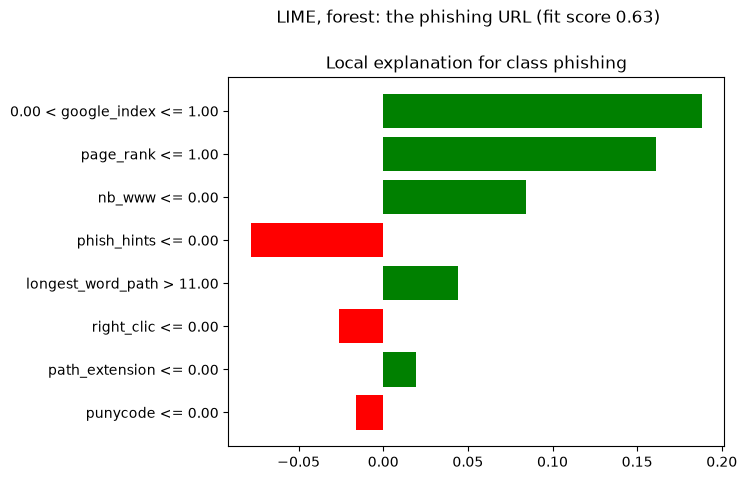

legitimate - fit score: 0.42    <- below 0.5: do not trust it much
   0.00 < google_index <= 1.00  +0.191
   iframe <= 0.00               -0.097
   nb_www <= 0.00               +0.080
   phish_hints <= 0.00          -0.073
   nb_star <= 0.00              -0.055
   nb_external_redirection <= 0.00 +0.052
   domain_age > 7025.25         -0.046
   nb_comma <= 0.00             -0.043


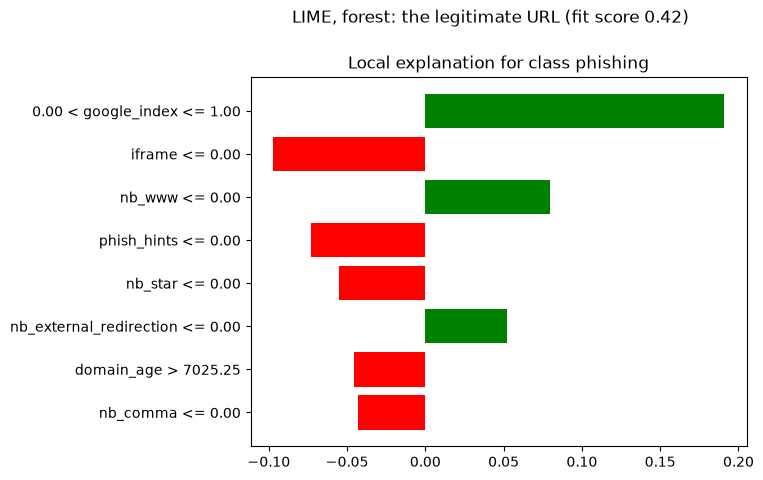

wrong - fit score: 0.48    <- below 0.5: do not trust it much
   0.00 < google_index <= 1.00  +0.186
   nb_www <= 0.00               +0.085
   web_traffic <= 0.00          +0.075
   phish_hints <= 0.00          -0.070
   nb_hyperlinks <= 8.00        +0.068
   punycode <= 0.00             +0.063
   nb_star <= 0.00              -0.053
   nb_dollar <= 0.00            -0.051


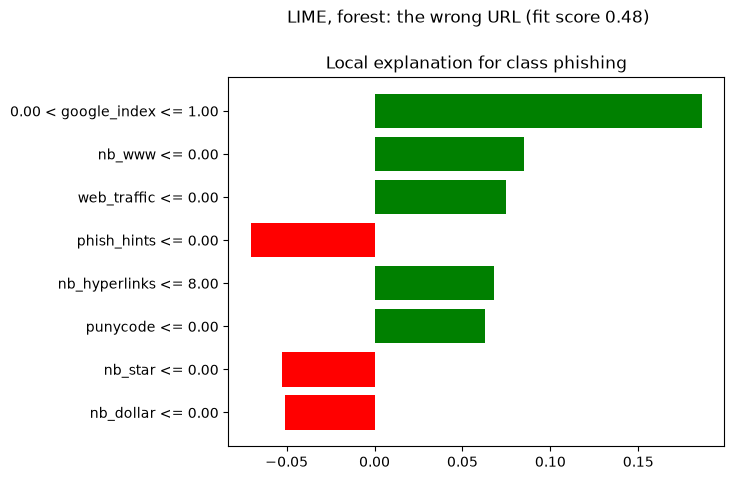

In [18]:
# STEP B6
from lime.lime_tabular import LimeTabularExplainer

def predict_fn(a, model=rf):
    # LIME sends plain numbers; give the model the column names it expects
    return model.predict_proba(pd.DataFrame(a, columns=X_train.columns))

lime_explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=list(X_train.columns),
    class_names=["legitimate", "phishing"],
    mode="classification",
    discretize_continuous=True,     # LIME's default: features become ranges
    random_state=42)

lime_exps = {}
for name, i in three:
    exp = lime_explainer.explain_instance(X_test.iloc[i].values, predict_fn,
                                          num_features=8, num_samples=5000)
    lime_exps[name] = exp
    flag = "   <- below 0.5: do not trust it much" if exp.score < 0.5 else ""
    print(name, "- fit score:", round(exp.score, 2), flag)
    for feature, weight in exp.as_list():
        print(f"   {feature:28s} {weight:+.3f}")
    fig = exp.as_pyplot_figure()
    fig.suptitle(f"LIME, forest: the {name} URL (fit score {exp.score:.2f})", y=1.02)
    fig.savefig(f"results/figures/B6_lime_{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

In [19]:
# STEP B6
# Do SHAP and LIME name the same top 3 features for each URL?
rows = []
for name, i in three:
    shap_vals = pd.Series(explainer(X_test.iloc[[i]])[:, :, 1].values[0], index=X_test.columns)
    shap_top3 = list(shap_vals.abs().sort_values(ascending=False).index[:3])
    lime_top3 = [X_test.columns[f] for f, weight in lime_exps[name].as_map()[1][:3]]  # sorted by |weight|
    rows.append({"name": name, "SHAP_top3": ", ".join(shap_top3), "LIME_top3": ", ".join(lime_top3),
                 "shared": len(set(shap_top3) & set(lime_top3)),
                 "LIME_fit_score": round(lime_exps[name].score, 3)})
top3_compare = pd.DataFrame(rows)
top3_compare.to_csv("results/tables/B6_shap_vs_lime_top3.csv", index=False)
top3_compare

,name,SHAP_top3,LIME_top3,shared,LIME_fit_score
0,phishing,"page_rank, google_index, length_hostname","google_index, page_rank, nb_www",2,0.627
1,legitimate,"google_index, web_traffic, nb_hyperlinks","google_index, iframe, nb_www",1,0.420
2,wrong,"google_index, nb_hyperlinks, nb_www","google_index, nb_www, web_traffic",2,0.481


<!-- STEP B6 -->
**What we see**

- **What fooled the forest on the wrong URL?** The blog looks like a fresh phishing page: Google has not
  indexed it (`google_index` = 1, +0.13 in SHAP), it has only 5 links (`nb_hyperlinks`, +0.08), no
  "www" (`nb_www`, +0.06) and no traffic rank (`web_traffic` = 0, +0.05). Almost nothing pushes the other
  way. A small blog on a free hosting platform has exactly the profile of a throw-away phishing page,
  which is why the external lookups mislead here.
- **Do SHAP and LIME name the same top 3?** Partly: 2 of 3 for the phishing URL, 1 of 3 for the
  legitimate one, 2 of 3 for the wrong one (`results/tables/B6_shap_vs_lime_top3.csv`). Both put
  `google_index` first for the legitimate and the wrong URL. For the phishing URL they swap
  `page_rank` and `google_index`.
- **LIME's fit score** is 0.63 for the phishing URL but **below 0.5 for the other two** (0.42 and
  0.48), so for those the straight line copies the forest badly and LIME should not be trusted much.
  In all three, LIME's top rule is "0 < `google_index` ≤ 1", because all three URLs are not indexed.
  For the legitimate URL that pushes toward phishing, but the site's traffic rank, links and domain
  age outweigh it, as the SHAP waterfall shows.

<!-- STEP C1 -->
# 7. Part C: Test the detector and the explanation

## Step C1: Remove the external features (ablation)

An ablation changes one thing and keeps the rest the same. Here we retrain the forest without the 7
external features: they need live lookups (WHOIS, DNS, Google, traffic rank), which are slow and not
always available, and a brand-new phishing site has no history yet.

In [20]:
# STEP C1
EXTERNAL = ["whois_registered_domain", "domain_registration_length",
            "domain_age", "web_traffic", "dns_record", "google_index",
            "page_rank"]
assert all(f in X_train.columns for f in EXTERNAL), "an external feature name is not a column"

X_train_ne = X_train.drop(columns=EXTERNAL)
X_test_ne = X_test.drop(columns=EXTERNAL)

rf_ne = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_ne.fit(X_train_ne, y_train)

print("with external   :", report(rf, X_test, y_test))
print("without external:", report(rf_ne, X_test_ne, y_test))

ablation = pd.DataFrame({"with external (87 features)": report(rf, X_test, y_test),
                         "without external (80 features)": report(rf_ne, X_test_ne, y_test)}).T
ablation.loc["change"] = ablation.iloc[1] - ablation.iloc[0]
ablation.index.name = "forest"
ablation.round(3).to_csv("results/tables/C1_ablation.csv")

sv_ne = shap.TreeExplainer(rf_ne)(X_test_ne.iloc[:500])[:, :, 1]
top_ne = pd.Series(np.abs(sv_ne.values).mean(axis=0), index=X_test_ne.columns)
print(top_ne.sort_values(ascending=False).head(5).round(4))
top_ne.sort_values(ascending=False).head(10).rename("mean_abs_shap").rename_axis("feature") \
    .to_csv("results/tables/C1_shap_top_without_external.csv")
ablation.round(3)

with external   : {'macro_F1': 0.965, 'recall': 0.968, 'ROC_AUC': 0.994, 'FAR': 0.038}


without external: {'macro_F1': 0.944, 'recall': 0.94, 'ROC_AUC': 0.984, 'FAR': 0.052}


nb_hyperlinks          0.0774
nb_www                 0.0706
phish_hints            0.0428
safe_anchor            0.0303
ratio_extHyperlinks    0.0296
dtype: float64


,macro_F1,recall,ROC_AUC,FAR
forest,,,,
with external (87 features),0.965,0.968,0.994,0.038
without external (80 features),0.944,0.940,0.984,0.052
change,-0.021,-0.028,-0.010,0.014


<!-- STEP C1 -->
**What we see**

- **How much did it drop?** Macro-F1 0.965 → 0.944 (−0.021), recall 0.968 → 0.940 (−0.028) and FAR
  0.038 → 0.052 (+0.014). On our 1,143 phishing and 1,143 legitimate test URLs that is roughly 30 more
  phishing sites missed and roughly 15 more false alarms.
- **What it looks at instead:** `nb_hyperlinks`, `nb_www`, `phish_hints`, `safe_anchor` and
  `ratio_extHyperlinks`, all taken from the URL text or the page itself.
- **Would we deploy it without live lookups?** As a first, fast filter, yes: it still catches 94% of
  phishing, needs no WHOIS/DNS/Google/traffic lookups, answers instantly, and does not depend on a
  history that a brand-new phishing site does not have yet. But not alone: every one of its top
  features is in the attacker's hands (they write the URL and the page), so it is easier to fool than
  the full model, whose strongest clues (`google_index`, `page_rank`) are hard to fake quickly.
  A sensible design uses the fast model at once and adds the lookups when they are available.

<!-- STEP C2 -->
## Step C2: Stability of LIME

LIME is random: we run it 5 times on the same URL (the surest phishing URL) with 5 different seeds and
count how often the top 3 stays the same. SHAP `TreeExplainer` is exact, so it should give the same
answer every time; we check that too instead of assuming it.

In [21]:
# STEP C2
top3_sets = []
for seed in [0, 1, 2, 3, 4]:
    ex = LimeTabularExplainer(X_train.values, random_state=seed,
                              feature_names=list(X_train.columns))
    e = ex.explain_instance(X_test.iloc[i_phish].values, predict_fn,
                            num_features=8, num_samples=5000)
    top3 = frozenset(feature for feature, weight in e.as_list()[:3])
    top3_sets.append(top3)
    print("seed", seed, sorted(top3))

most_common = max(set(top3_sets), key=top3_sets.count)
lime_same = top3_sets.count(most_common)
print(lime_same, "of 5 runs give the same top 3")

# SHAP: explain the same URL 5 times and compare the values
shap_runs = [explainer(X_test.iloc[[i_phish]])[:, :, 1].values[0] for _ in range(5)]
shap_same = sum(np.array_equal(r, shap_runs[0]) for r in shap_runs)
print("SHAP TreeExplainer:", shap_same, "of 5 runs give exactly the same values")

stability = pd.DataFrame({"seed": [0, 1, 2, 3, 4],
                          "LIME_top3": [", ".join(sorted(s)) for s in top3_sets],
                          "same_as_most_common": [s == most_common for s in top3_sets]})
stability.to_csv("results/tables/C2_lime_stability.csv", index=False)
print(f"summary: LIME {lime_same} of 5, SHAP {shap_same} of 5")

seed 0 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 1 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 2 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 3 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']


seed 4 ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']
5 of 5 runs give the same top 3


SHAP TreeExplainer: 5 of 5 runs give exactly the same values
summary: LIME 5 of 5, SHAP 5 of 5


<!-- STEP C2 -->
**What we see**

- **LIME: 5 of 5** runs gave the same top 3 (`google_index`, `page_rank`, `nb_www` as ranges), and
  **SHAP: 5 of 5** runs gave exactly the same values. On this URL, LIME was stable.
- That is the easiest case, though: the forest is 100% sure about this URL, three strong features dominate,
  and LIME's fit score is 0.63. For the legitimate and the wrong URL the fit scores were below 0.5
  (step B6), so LIME's line copies the forest badly there, and the top 3 may move more between seeds.
  SHAP `TreeExplainer` is exact, so it cannot change between runs on any URL.

<!-- STEP D1 -->
# 8. Part D: From explanations to rules (BRB)

Now we take the two most important features and build a Belief Rule-Based expert system (BRB) with
them, the same way as in the BRB slides.

## Step D1: Choose your two features

We take the top of the forest's SHAP ranking (step B2), skipping 0/1 features like `google_index`,
because a BRB needs Low, Medium and High. We also check that each feature really gets three different
referential values (5th percentile < median < 95th percentile, as used in step D3): a feature with many
equal values could collapse two levels into one.

In [22]:
# STEP D1
# The BRB needs Low / Medium / High, so skip 0/1 features
ranked = [f for f in shap_top.index if X_train[f].nunique() > 2]
F1, F2 = ranked[0], ranked[1]         # you may change these

# Check: three different referential values from the training data (the same rule as in step D3)
def three_levels(f):
    r = X_train[f].quantile([0.05, 0.50, 0.95]).round(2).tolist()
    return r[0] < r[1] < r[2]

usable = [f for f in ranked if three_levels(f)]
if [F1, F2] != usable[:2]:
    print("skipped (two referential values are equal):",
          [f for f in ranked[:ranked.index(usable[1])] if f not in usable])
    F1, F2 = usable[0], usable[1]

skipped_binary = [f for f in shap_top.index[:ranked.index(F2) + 1] if f not in ranked]
print("0/1 features skipped:", skipped_binary)
print("Antecedents:", F1, "and", F2)

0/1 features skipped: ['google_index']
Antecedents: page_rank and nb_hyperlinks


<!-- STEP D1 -->
**Our two features.** The top of the SHAP ranking is `google_index`, a 0/1 feature, so it is skipped.
The next two both have three different referential values:

- **`page_rank`** (0–10): how well-linked the site is. Phishing sites are new and nobody links to them,
  so they usually score low (in the whole dataset, 96% of URLs with page rank 0 are phishing).
- **`nb_hyperlinks`**: how many links the page has. Phishing pages are often a single fake login form
  with very few links, while real sites link to many of their own pages.

Both are also in the top 5 of almost every list in step B4, so a BRB built on them uses clues that all
our models agree on.

<!-- STEP D2 -->
## Step D2: The BRB code

Step 1 splits a value between its two nearest reference values. Step 2 finds how strongly each of the
9 rules matches. Step 3 combines the rules with Evidential Reasoning, so the output also has an
**Unknown** part.

In [23]:
# STEP D2
# Step 1: input transformation (same as in the BRB slides)
def transform_to_belief(value, references):
    value = float(value)
    n = len(references)
    belief = [0.0] * n
    if value <= references[0]:
        belief[0] = 1.0
        return belief
    if value >= references[-1]:
        belief[-1] = 1.0
        return belief
    for i in range(n - 1):
        lower, upper = references[i], references[i + 1]
        if lower <= value <= upper:
            d = upper - lower
            belief[i] = (upper - value) / d
            belief[i + 1] = (value - lower) / d
            return belief
    return belief

# Step 2: rule activation weights (9 rules = 3 x 3)
def calculate_activation_weights(belief1, belief2):
    d1 = attribute_weights[0]
    d2 = attribute_weights[1]
    activation = []
    for i in range(3):
        for j in range(3):
            w = (rule_weights[i * 3 + j]
                 * belief1[i] ** d1 * belief2[j] ** d2)
            activation.append(w)
    total = sum(activation)
    if total == 0:
        return [0.0] * len(activation)
    return [x / total for x in activation]

# Step 3: Evidential Reasoning (ER)
def combine_two(b1, ig1, b2, ig2, n=3):
    conflict = sum(b1[i] * b2[j] for i in range(n)
                   for j in range(n) if i != j)
    k = 1 / (1 - conflict)
    new_b = [k * (b1[i] * b2[i] + b1[i] * ig2 + ig1 * b2[i])
             for i in range(n)]
    return new_b, k * (ig1 * ig2)

def er_aggregation(weights, rules, n=3):
    act = [(w, r) for w, r in zip(weights, rules) if w > 0]
    bel = [[w * v for v in r] for w, r in act]
    ign = [1 - sum(b) for b in bel]
    fb, fg = bel[0], ign[0]
    for i in range(1, len(bel)):
        fb, fg = combine_two(fb, fg, bel[i], ign[i], n)
    return fb, fg

def brbes_inference(v1, v2):
    belief1 = transform_to_belief(v1, refs1)
    belief2 = transform_to_belief(v2, refs2)
    aw = calculate_activation_weights(belief1, belief2)
    final_belief, ignorance = er_aggregation(aw, rules)
    return belief1, belief2, aw, final_belief, ignorance

<!-- STEP D3 -->
## Step D3: Referential values and the 9 rules

Low / Medium / High are the 5th percentile, median and 95th percentile of the **training** data. In
the slides an expert wrote the rules by hand; here we start from the data: for each rule we count how
many of the training URLs that match it are phishing (share 0 = Low risk, 0.5 = Medium, 1 = High).
The **support** says how much data stands behind each rule.

In [24]:
# STEP D3
# Referential values Low / Medium / High for each antecedent,
# taken from the TRAINING data: 5th percentile, median, 95th percentile
refs1 = X_train[F1].quantile([0.05, 0.50, 0.95]).round(2).tolist()
refs2 = X_train[F2].quantile([0.05, 0.50, 0.95]).round(2).tolist()
print(F1, "Low/Medium/High =", refs1)
print(F2, "Low/Medium/High =", refs2)

consequent_refs = ["Low", "Medium", "High"]   # consequent: phishing risk
attribute_weights = [1.0, 1.0]
rule_weights = [1.0] * 9

# Start the 9 rules from the training data.
# For each rule: how many of the URLs that activate it are phishing?
A = np.array([calculate_activation_weights(transform_to_belief(a, refs1),
                                           transform_to_belief(b, refs2))
              for a, b in X_train[[F1, F2]].values])      # (6858 URLs, 9 rules)
support = A.sum(axis=0)                                   # how much data per rule
phish = (A * y_train.values[:, None]).sum(axis=0)         # phishing part
share = phish / np.maximum(support, 1e-9)

# Turn each phishing share into beliefs in Low / Medium / High risk
# (share 0 -> Low, 0.5 -> Medium, 1 -> High), with the same Step 1 function
rules = [transform_to_belief(s, [0.0, 0.5, 1.0]) for s in share]

names = ["Low", "Med", "High"]
for k in range(9):
    i, j = k // 3, k % 3
    print(f"R{k + 1}: {F1}={names[i]:4s} {F2}={names[j]:4s} "
          f"-> {[round(x, 2) for x in rules[k]]}  (support {support[k]:.0f})")

# The rule table for the report
rule_table = pd.DataFrame({
    "rule": [f"R{k + 1}" for k in range(9)],
    F1: [["Low", "Medium", "High"][k // 3] for k in range(9)],
    F2: [["Low", "Medium", "High"][k % 3] for k in range(9)],
    "belief_Low": [round(r[0], 3) for r in rules],
    "belief_Medium": [round(r[1], 3) for r in rules],
    "belief_High": [round(r[2], 3) for r in rules],
    "phishing_share": share.round(3),
    "support": support.round(1),
})
rule_table.to_csv("results/tables/D3_rules.csv", index=False)

# A rule with (almost) no data gets share 0 and claims "Low risk" without evidence
thin = rule_table[rule_table["support"] < 20]
print("rules with support below 20:", "none" if thin.empty else list(thin["rule"]))

page_rank Low/Medium/High = [0.0, 3.0, 8.0]
nb_hyperlinks Low/Medium/High = [0.0, 33.0, 325.0]


R1: page_rank=Low  nb_hyperlinks=Low  -> [0.0, 0.11, 0.89]  (support 1106)
R2: page_rank=Low  nb_hyperlinks=Med  -> [0.0, 0.32, 0.68]  (support 960)
R3: page_rank=Low  nb_hyperlinks=High -> [0.0, 0.75, 0.25]  (support 141)
R4: page_rank=Med  nb_hyperlinks=Low  -> [0.0, 0.63, 0.37]  (support 854)
R5: page_rank=Med  nb_hyperlinks=Med  -> [0.43, 0.57, 0.0]  (support 1650)
R6: page_rank=Med  nb_hyperlinks=High -> [0.84, 0.16, 0.0]  (support 627)
R7: page_rank=High nb_hyperlinks=Low  -> [0.0, 0.77, 0.23]  (support 344)
R8: page_rank=High nb_hyperlinks=Med  -> [0.58, 0.42, 0.0]  (support 773)
R9: page_rank=High nb_hyperlinks=High -> [0.96, 0.04, 0.0]  (support 403)
rules with support below 20: none


In [25]:
# STEP D3
# Sanity checks of the engine (step D2) with these referential values
assert transform_to_belief(refs1[1], refs1) == [0.0, 1.0, 0.0]       # a level value: full belief
half = (refs1[0] + refs1[1]) / 2
assert np.allclose(transform_to_belief(half, refs1), [0.5, 0.5, 0.0])  # halfway: 0.5 / 0.5
assert np.allclose(A.sum(axis=1), 1.0)                                  # 9 weights sum to 1 per URL
b1, b2, aw, fb, ig = brbes_inference(X_train[F1].iloc[0], X_train[F2].iloc[0])
assert abs(sum(fb) + ig - 1) < 1e-9                                     # beliefs + Unknown = 1
print("engine sanity checks passed")

engine sanity checks passed


<!-- STEP D3 -->
**Do the rules make sense?** Yes, mostly:

- The two extremes are clear: R1 (low page rank, few links) → High risk 0.89, and R9 (high page rank,
  many links) → Low risk 0.96.
- Risk falls when either feature grows. With a Low page rank, High risk goes 0.89 → 0.68 → 0.25 as the
  links go Low → Medium → High, and with Low links it goes 0.89 → 0.37 → 0.23 as the page rank grows.
- No rule is empty: the smallest support is R3 with about 141 URLs, so no rule claims "Low risk"
  without data.
- The middle rules are uncertain: R5 (both Medium) is {Low 0.43, Medium 0.57}. Two features cannot
  separate those URLs well, which is why the BRB is much weaker than the full forest (step D4).

<!-- STEP D4 -->
## Step D4: Use the BRB as a phishing detector

`BRBDetector` turns the beliefs into one phishing score with the utility (Low = 0, Medium = 0.5,
High = 1), so `report()` works unchanged. For a fair comparison we also train a small tree and a
forest on the same two features.

In [26]:
# STEP D4
def brb_predict_proba(X):
    """X: array (n, 2) of [F1, F2].
    Returns (n, 4): Low, Medium, High, Unknown."""
    X = np.atleast_2d(X)
    out = []
    for v1, v2 in X:
        fb, ig = brbes_inference(v1, v2)[3:]
        out.append(fb + [ig])
    return np.array(out)

class BRBDetector:
    """Makes the BRB look like a scikit-learn model, so report() works."""
    def predict_proba(self, X):
        B = brb_predict_proba(X[[F1, F2]].values)
        # utility: Low = 0, Medium = 0.5, High = 1; Unknown is left out
        u = (0.5 * B[:, 1] + B[:, 2]) / (1 - B[:, 3])
        return np.column_stack([1 - u, u])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

brb = BRBDetector()

# Fair comparison: other models that see ONLY the same two features
from sklearn.tree import export_text
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train[[F1, F2]], y_train)
rf2 = RandomForestClassifier(n_estimators=300, random_state=42,
                             n_jobs=-1)
rf2.fit(X_train[[F1, F2]], y_train)

print("BRB, 2 features   :", report(brb, X_test, y_test))
print("tree, 2 features  :", report(tree2, X_test[[F1, F2]], y_test))
print("forest, 2 features:", report(rf2, X_test[[F1, F2]], y_test))
print("forest, all 87    :", report(rf, X_test, y_test))

brb_scores = pd.DataFrame({
    "BRB, 2 features": report(brb, X_test, y_test),
    "tree (depth 2), 2 features": report(tree2, X_test[[F1, F2]], y_test),
    "forest, 2 features": report(rf2, X_test[[F1, F2]], y_test),
    "forest, all 87 features": report(rf, X_test, y_test),
}).T
brb_scores.index.name = "model"
brb_scores.to_csv("results/tables/D4_brb_scores.csv")
print("the depth-2 tree on the same two features:")
print(export_text(tree2, feature_names=[F1, F2]))
brb_scores

BRB, 2 features   : {'macro_F1': 0.802, 'recall': 0.773, 'ROC_AUC': 0.914, 'FAR': 0.169}
tree, 2 features  : {'macro_F1': 0.803, 'recall': 0.948, 'ROC_AUC': 0.885, 'FAR': 0.334}


forest, 2 features: {'macro_F1': 0.847, 'recall': 0.842, 'ROC_AUC': 0.927, 'FAR': 0.148}


forest, all 87    : {'macro_F1': 0.965, 'recall': 0.968, 'ROC_AUC': 0.994, 'FAR': 0.038}


the depth-2 tree on the same two features:
|--- nb_hyperlinks <= 51.50
|   |--- page_rank <= 1.50
|   |   |--- class: 1
|   |--- page_rank >  1.50
|   |   |--- class: 1
|--- nb_hyperlinks >  51.50
|   |--- page_rank <= 1.50
|   |   |--- class: 1
|   |--- page_rank >  1.50
|   |   |--- class: 0



,macro_F1,recall,ROC_AUC,FAR
model,,,,
"BRB, 2 features",0.802,0.773,0.914,0.169
"tree (depth 2), 2 features",0.803,0.948,0.885,0.334
"forest, 2 features",0.847,0.842,0.927,0.148
"forest, all 87 features",0.965,0.968,0.994,0.038


<!-- STEP D4 -->
**BRB vs the small tree.** Their macro-F1 is almost the same (0.802 against 0.803), as the lab
predicted, but they make very different mistakes:

- The **depth-2 tree** catches 94.8% of phishing but flags **33.4% of legitimate URLs**. Its rules show
  why: it only calls a URL legitimate when it has more than 51 links **and** a page rank above 1.5.
- The **BRB** catches 77.3% of phishing and flags 16.9% of legitimate URLs.

A security team would usually prefer the **BRB**. A filter that blocks one in three legitimate sites
floods the analysts with false alarms, and users learn to ignore it. The BRB's graded output
(Low/Medium/High + Unknown) also lets the team use a lower threshold, or send "Medium with high Unknown"
URLs to a human. Where a missed phishing site costs much more than a false alarm (e.g. a mail filter in
front of a bank), the tree's recall could win. Both are far below the full forest (0.965); the forest on
the same two features reaches 0.847, so a lot of information lives in the other 85 features.

<!-- STEP D5 -->
## Step D5: Explain one URL: the rules, LIME and SHAP

First the BRB explains itself: which rules fire for the forest's mistake from step B5, and how much is
Unknown. Then we treat the BRB as a black box, as in the slides, and explain its High-risk belief with
LIME and SHAP.

In [27]:
# STEP D5
# The BRB explains itself: which rules fire for the mistake from step B5?
url = X_test[[F1, F2]].iloc[i_wrong].values
b1, b2, aw, fb, ig = brbes_inference(*url)
print(F1, "=", url[0], "  ", F2, "=", url[1])
for k in range(9):
    if aw[k] > 0:
        print(f"   rule R{k + 1} fires with weight {aw[k]:.2f}"
              f"   (rule belief Low/Medium/High {[round(x, 2) for x in rules[k]]},"
              f" adds {aw[k] * rules[k][2]:.2f} High before ER)")
print("belief Low/Medium/High:", [round(x, 3) for x in fb])
print("Unknown:", round(ig, 3), "  true label:", y_test.iloc[i_wrong])
print("BRB phishing score:", round(float(brb.predict_proba(X_test.iloc[[i_wrong]])[0, 1]), 3))

page_rank = 2.0    nb_hyperlinks = 5.0
   rule R1 fires with weight 0.28   (rule belief Low/Medium/High [0.0, 0.11, 0.89], adds 0.25 High before ER)
   rule R2 fires with weight 0.05   (rule belief Low/Medium/High [0.0, 0.32, 0.68], adds 0.03 High before ER)
   rule R4 fires with weight 0.57   (rule belief Low/Medium/High [0.0, 0.63, 0.37], adds 0.21 High before ER)
   rule R5 fires with weight 0.10   (rule belief Low/Medium/High [0.43, 0.57, 0.0], adds 0.00 High before ER)
belief Low/Medium/High: [0.015, 0.333, 0.337]
Unknown: 0.315   true label: 0
BRB phishing score: 0.735


LIME (High): [('page_rank', -0.202576143550484), ('nb_hyperlinks', -0.17920134610547675)]
fit score  : 0.738


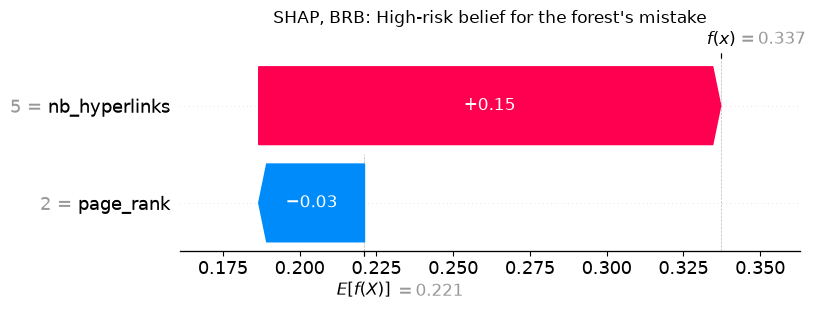

In [28]:
# STEP D5
feature_names = [F1, F2]
X_ref = X_train[[F1, F2]].values           # reference data for LIME and SHAP

brb_lime = LimeTabularExplainer(X_ref, feature_names=feature_names,
                                discretize_continuous=False,
                                random_state=42)
lime_exp = brb_lime.explain_instance(url, brb_predict_proba,
                                     labels=(2,),        # 2 = "High" risk
                                     num_features=2, num_samples=2000)
print("LIME (High):", lime_exp.as_list(label=2))
print("fit score  :", round(lime_exp.score, 3))

background = shap.sample(X_ref, 100, random_state=0)   # "ordinary" URLs
brb_shap = shap.KernelExplainer(brb_predict_proba, background)
sv_brb = brb_shap(url.reshape(1, -1), silent=True)   # silent: no progress bar
sv_brb.feature_names = feature_names
shap.plots.waterfall(sv_brb[0, :, 2], show=False)     # the "High" risk belief
plt.title("SHAP, BRB: High-risk belief for the forest's mistake")
plt.savefig("results/figures/D5_shap_brb_waterfall_high.png", dpi=150, bbox_inches="tight")
plt.show()

<!-- STEP D5 -->
**The expert's hand-edit.** As the lab suggests, we act as the expert and change one rule by hand:
R4 (`F1` Medium, `F2` Low) becomes {Low 0.0, Medium 0.2, High 0.8}. We rerun the D4 scores and the D5
trace with the edited rules, then put the data-driven rules back, so every later cell uses the rules
from step D3.

In [29]:
# STEP D5
rules_from_data = [list(r) for r in rules]
edited = [list(r) for r in rules]
edited[3] = [0.0, 0.2, 0.8]                          # R4, set by the "expert"
print("R4 from the data:", [round(x, 2) for x in rules_from_data[3]], "-> edited:", edited[3])
try:
    rules = edited
    print("BRB with the edited rule:", report(brb, X_test, y_test))
    fb_e, ig_e = brbes_inference(*url)[3:]
    print("mistake URL, belief Low/Medium/High:", [round(x, 3) for x in fb_e],
          " Unknown:", round(ig_e, 3))
finally:
    rules = rules_from_data                          # back to the data-driven rules
print("BRB with the data rules :", report(brb, X_test, y_test))

R4 from the data: [0.0, 0.63, 0.37] -> edited: [0.0, 0.2, 0.8]
BRB with the edited rule: {'macro_F1': 0.818, 'recall': 0.818, 'ROC_AUC': 0.905, 'FAR': 0.183}
mistake URL, belief Low/Medium/High: [0.014, 0.128, 0.557]  Unknown: 0.3


BRB with the data rules : {'macro_F1': 0.802, 'recall': 0.773, 'ROC_AUC': 0.914, 'FAR': 0.169}


<!-- STEP D5 -->
**What we see**

- **Was the BRB fooled too? Yes.** For `graphicsfairy.blogspot.ru` (legitimate) the BRB gives High 0.337,
  Medium 0.333, Low 0.015 and **Unknown 0.315**, a phishing score of 0.735. With only 5 links
  (near the Low level 0) and page rank 2 (between Low 0 and Medium 3), it looks like a phishing page to
  the rules too. The Unknown part is large because the weight is split over four partly-active
  rules: in the lab's recursive ER, that share is left unassigned. Extra X5 shows that the analytical
  ER spreads it over the levels (Low 0.02, Medium 0.49, High 0.49) and gives the same phishing score.
- **Which rule is most to blame?** R4 (page rank Medium, links Low) fires the strongest (weight 0.57),
  but R1 (page rank Low, links Low, High 0.89) adds the most High-risk belief (0.25, against 0.21 from R4).
  Both have "few links" in common.
- **Do LIME and SHAP agree?** Not fully. SHAP says the few links push High risk up the most (+0.15) and
  page rank 2 pulls it down slightly (−0.03). That matches the rules: both big rules fire because of "links
  Low". LIME (fit score 0.74) gives both inputs negative weights (more of either lowers High risk) and
  ranks `page_rank` slightly first. With `discretize_continuous=False` LIME's weights are local slopes,
  "how fast High risk changes", not contributions. SHAP answers the question "what pushed this URL up",
  and that answer agrees with the rules.
- **The expert's hand-edit** (R4 → {Medium 0.2, High 0.8}) raises recall 0.773 → 0.818 but also FAR
  0.169 → 0.183 (macro-F1 0.802 → 0.818). It makes this mistake worse: High risk 0.337 → 0.557. One hand-
  edited rule changes both the scores and the explanation, which is the point of a BRB: the knowledge
  sits in rules that a person can read and change.

<!-- STEP X1 -->
# Optional extras

## Extra X1: Which CUTOFF for pseudo-labelling?

Step A8 used `CUTOFF = 0.9`; the lab suggests also trying 0.85 and 0.95. A lower cutoff adds more
pseudo-labels but more wrong ones; a higher cutoff adds fewer, cleaner ones. We repeat the same three
rounds for each cutoff and compare on the **validation** set (the test set is not used to choose).
`y_hidden` is again only used to count how many guesses were right.

In [30]:
# STEP X1
def pseudo_label(cutoff):
    """Step A8 with another CUTOFF: returns the final forest and the guess statistics."""
    X_now, y_now = X_lab.copy(), y_lab.copy()
    pool = X_unlab.copy()
    model = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    for rnd in [1, 2, 3]:
        model.fit(X_now, y_now)
        p = model.predict_proba(pool)[:, 1]
        sure = (p >= cutoff) | (1 - p >= cutoff)
        guess = pd.Series((p[sure] >= 0.5).astype(int), index=pool.index[sure])
        X_now = pd.concat([X_now, pool[sure]])
        y_now = pd.concat([y_now, guess])
        pool = pool[~sure]
    model.fit(X_now, y_now)
    guesses = y_now.iloc[len(y_lab):]
    accuracy = float((guesses == y_hidden.loc[guesses.index]).mean())   # check only
    return model, len(guesses), accuracy

rows = [{"model": "forest (5%), no pseudo-labels", "cutoff": None, "guesses_added": 0,
         "guess_accuracy": None, **report(rf_few, X_val, y_val)}]
for cutoff in [0.85, 0.90, 0.95]:
    model, n_guesses, accuracy = pseudo_label(cutoff)
    rows.append({"model": "semi-supervised", "cutoff": cutoff, "guesses_added": n_guesses,
                 "guess_accuracy": round(accuracy, 4), **report(model, X_val, y_val)})
cutoff_sweep = pd.DataFrame(rows)
cutoff_sweep.to_csv("results/tables/X1_cutoff_sweep.csv", index=False)

# CUTOFF 0.9 must reproduce step A8
assert cutoff_sweep.loc[cutoff_sweep["cutoff"] == 0.90, "macro_F1"].item() == report(rf_semi, X_val, y_val)["macro_F1"]
cutoff_sweep

,model,cutoff,guesses_added,guess_accuracy,macro_F1,recall,ROC_AUC,FAR
0,"forest (5%), no pseudo-labels",NaN,0,NaN,0.938,0.946,0.984,0.069
1,semi-supervised,0.85,5120,0.9814,0.935,0.945,0.983,0.075
2,semi-supervised,0.90,4265,0.9885,0.931,0.946,0.982,0.083
3,semi-supervised,0.95,2780,0.9921,0.931,0.948,0.983,0.085


<!-- STEP X1 -->
**What we see**

- The trade-off is as expected: CUTOFF 0.85 adds 5,120 guesses (98.1% right), 0.90 adds 4,265 (98.9%),
  0.95 adds 2,780 (99.2%).
- On validation, 0.85 is slightly best (macro-F1 0.935, FAR 0.075), but **no cutoff beats the forest
  on the 5% labels alone** (0.938, FAR 0.069). All three add false alarms. So the verdict of step A10
  does not depend on the cutoff: here the pseudo-labels do not help.

<!-- STEP X2 -->
## Extra X2: LIME stability on all three URLs

Step C2 tested LIME on the easiest URL only. Here we repeat the 5-seed test on all three URLs from
step B5, including the two where LIME's fit score was below 0.5, and count again how often SHAP gives
exactly the same values.

In [31]:
# STEP X2
rows = []
for name, i in three:
    sets, scores = [], []
    for seed in [0, 1, 2, 3, 4]:
        ex = LimeTabularExplainer(X_train.values, random_state=seed,
                                  feature_names=list(X_train.columns))
        e = ex.explain_instance(X_test.iloc[i].values, predict_fn,
                                num_features=8, num_samples=5000)
        sets.append(frozenset(feature for feature, weight in e.as_list()[:3]))
        scores.append(e.score)
    most = max(sets, key=sets.count)       # ties: the first one; a set's order would vary per run
    shap_runs = [explainer(X_test.iloc[[i]])[:, :, 1].values[0] for _ in range(5)]
    rows.append({"url": name, "LIME_same_top3_of_5": sets.count(most),
                 "LIME_distinct_top3_sets": len(set(sets)),
                 "LIME_fit_min": round(min(scores), 3), "LIME_fit_max": round(max(scores), 3),
                 "most_common_top3": ", ".join(sorted(most)),
                 "SHAP_identical_of_5": sum(np.array_equal(r, shap_runs[0]) for r in shap_runs)})
    print(name, [sorted(s) for s in sets])
x2_stability = pd.DataFrame(rows)
x2_stability.to_csv("results/tables/X2_lime_stability_three_urls.csv", index=False)
x2_stability

phishing [['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'page_rank <= 1.00']]


legitimate [['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'path_extension <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'phish_hints <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_dollar <= 0.00', 'punycode <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_star <= 0.00', 'nb_www <= 0.00'], ['0.00 < google_index <= 1.00', 'iframe <= 0.00', 'punycode <= 0.00']]


wrong [['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'phish_hints <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'phish_hints <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'phish_hints <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_hyperlinks <= 8.00', 'nb_www <= 0.00'], ['0.00 < google_index <= 1.00', 'nb_www <= 0.00', 'punycode <= 0.00']]


,url,LIME_same_top3_of_5,LIME_distinct_top3_sets,LIME_fit_min,LIME_fit_max,most_common_top3,SHAP_identical_of_5
0,phishing,5,1,0.620,0.643,"0.00 < google_index <= 1.00, nb_www <= 0.00, p...",5
1,legitimate,1,5,0.415,0.443,"0.00 < google_index <= 1.00, nb_www <= 0.00, p...",5
2,wrong,3,3,0.463,0.498,"0.00 < google_index <= 1.00, nb_www <= 0.00, p...",5


<!-- STEP X2 -->
**What we see**

- **LIME is only stable where it fits well.** On the phishing URL (fit 0.62–0.64) all 5 seeds give the
  same top 3. On the wrong URL (fit 0.46–0.50) only 3 of 5 agree. On the legitimate URL (fit
  0.42–0.44) **all 5 seeds give a different top 3**: only `google_index` is always there, and the
  other two places go to small features like `punycode`, `nb_star` or `iframe`.
- **SHAP gives exactly the same values 5 of 5 times on every URL.**
- So the C2 result (LIME 5 of 5) was the best case. A low fit score is a warning that LIME's
  explanation will also change from run to run.

<!-- STEP X3 -->
## Extra X3: A second BRB on a pair chosen by hand

Step D1 took the two top SHAP features. A security analyst might instead choose by hand:
**`domain_age`** (new domains are suspicious; the site's history) and **`length_url`** (long URLs can
hide the real domain; how the address looks). Both get three different referential values. (The lab's
example pair `page_rank` + `nb_www` cannot be used: `nb_www` has 5th percentile = median = 0.)
We build the BRB exactly as in step D3 and score it as in step D4. The step-D rules are put back
afterwards.

In [32]:
# STEP X3
def brb_for_pair(f1, f2):
    """Build the D3 rules for another feature pair, score them as in D4, then restore the D rules."""
    global F1, F2, refs1, refs2, rules
    saved = (F1, F2, refs1, refs2, rules)
    try:
        F1, F2 = f1, f2
        refs1 = X_train[f1].quantile([0.05, 0.50, 0.95]).round(2).tolist()
        refs2 = X_train[f2].quantile([0.05, 0.50, 0.95]).round(2).tolist()
        assert refs1[0] < refs1[1] < refs1[2] and refs2[0] < refs2[1] < refs2[2]
        A2 = np.array([calculate_activation_weights(transform_to_belief(a, refs1),
                                                    transform_to_belief(b, refs2))
                       for a, b in X_train[[f1, f2]].values])
        sup = A2.sum(axis=0)
        shr = (A2 * y_train.values[:, None]).sum(axis=0) / np.maximum(sup, 1e-9)
        rules = [transform_to_belief(s, [0.0, 0.5, 1.0]) for s in shr]
        table = pd.DataFrame({
            "rule": [f"R{k + 1}" for k in range(9)],
            f1: [["Low", "Medium", "High"][k // 3] for k in range(9)],
            f2: [["Low", "Medium", "High"][k % 3] for k in range(9)],
            "belief_Low": [round(r[0], 3) for r in rules],
            "belief_Medium": [round(r[1], 3) for r in rules],
            "belief_High": [round(r[2], 3) for r in rules],
            "phishing_share": shr.round(3), "support": sup.round(1)})
        scores = report(brb, X_test, y_test)
        score_wrong = float(brb.predict_proba(X_test.iloc[[i_wrong]])[0, 1])
        return refs1, refs2, table, scores, score_wrong
    finally:
        F1, F2, refs1, refs2, rules = saved

pairs = [(F1, F2, "SHAP top 2 (step D1)"), ("domain_age", "length_url", "chosen by hand")]
rows = []
for f1, f2, how in pairs:
    r1, r2, table, scores, score_wrong = brb_for_pair(f1, f2)
    t2 = DecisionTreeClassifier(max_depth=2, random_state=42).fit(X_train[[f1, f2]], y_train)
    rows.append({"pair": f"{f1} + {f2}", "chosen": how, "model": "BRB", **scores,
                 "score_on_mistake_url": round(score_wrong, 3)})
    rows.append({"pair": f"{f1} + {f2}", "chosen": how, "model": "tree (depth 2)",
                 **report(t2, X_test[[f1, f2]], y_test), "score_on_mistake_url":
                 round(float(t2.predict_proba(X_test[[f1, f2]].iloc[[i_wrong]])[0, 1]), 3)})
    if how == "chosen by hand":
        print(f1, "Low/Medium/High =", r1, "|", f2, "Low/Medium/High =", r2)
        print(table.to_string(index=False))
        table.to_csv("results/tables/X3_rules_domain_age_length_url.csv", index=False)

x3_pairs = pd.DataFrame(rows)
x3_pairs.to_csv("results/tables/X3_brb_pairs.csv", index=False)
print("step-D rules restored:", F1, F2, refs1, refs2)
x3_pairs

domain_age Low/Medium/High = [-1.0, 4003.0, 8760.45] | length_url Low/Medium/High = [22.0, 47.0, 132.0]
rule domain_age length_url  belief_Low  belief_Medium  belief_High  phishing_share  support
  R1        Low        Low       0.078          0.922         0.00           0.461    790.3
  R2        Low     Medium       0.000          0.530         0.47           0.735   1077.2
  R3        Low       High       0.000          0.230         0.77           0.885    405.3
  R4     Medium        Low       0.417          0.583         0.00           0.292    683.8
  R5     Medium     Medium       0.005          0.995         0.00           0.497   1417.5
  R6     Medium       High       0.000          0.490         0.51           0.755    564.9
  R7       High        Low       0.504          0.496         0.00           0.248    445.8
  R8       High     Medium       0.453          0.547         0.00           0.273   1124.3
  R9       High       High       0.053          0.947         0.00  

,pair,chosen,model,macro_F1,recall,ROC_AUC,FAR,score_on_mistake_url
0,page_rank + nb_hyperlinks,SHAP top 2 (step D1),BRB,0.802,0.773,0.914,0.169,0.735
1,page_rank + nb_hyperlinks,SHAP top 2 (step D1),tree (depth 2),0.803,0.948,0.885,0.334,0.563
2,domain_age + length_url,chosen by hand,BRB,0.717,0.627,0.788,0.188,0.366
3,domain_age + length_url,chosen by hand,tree (depth 2),0.736,0.652,0.748,0.176,0.300


<!-- STEP X3 -->
**What we see**

- **The hand-picked pair is clearly worse:** the BRB drops from macro-F1 0.802 to 0.717 (recall 0.773
  → 0.627), and the depth-2 tree on the same pair also drops (0.803 → 0.736). SHAP picked better
  features than intuition did.
- Its rules are less clear-cut: only "young domain + long URL" (R3, High 0.77) is a strong signal. The
  "Low" level of `domain_age` is −1, which means *unknown*, so R1–R3 mix unknown domains with young ones.
  Several rules sit near 50% phishing (R1, R5, R9), which a BRB can only call Medium.
- **But it is not fooled by the forest's mistake:** the blog gets a phishing score of 0.366 (0.735 with
  the SHAP pair), because `graphicsfairy.blogspot.ru` is an old domain with a short URL. Different
  features make different mistakes, which is an argument for combining evidence.

<!-- STEP X4 -->
## Extra X4: Would the validation set choose the same two features?

Step D1 ranks the features with SHAP on **test** URLs, and step D4 then scores the BRB on the same test
set. To remove any doubt about test leakage, we rank the features again on 500 **validation** URLs with
the same forest and explainer and apply the same D1 rule.

In [33]:
# STEP X4
sv_val = explainer(X_val.iloc[:500])[:, :, 1]
shap_top_val = pd.Series(np.abs(sv_val.values).mean(axis=0),
                         index=X_val.columns).sort_values(ascending=False)
ranked_val = [f for f in shap_top_val.index
              if X_train[f].nunique() > 2 and three_levels(f)]
print("validation choice:", ranked_val[:2], "| test choice (D1):", [F1, F2])
assert ranked_val[:2] == [F1, F2], "the validation set would choose other features"

x4_ranking = pd.DataFrame({"rank": range(1, 11),
                           "SHAP on test (D1)": shap_top.index[:10],
                           "SHAP on validation": shap_top_val.index[:10]})
print("shared top-10 features:", len(set(shap_top.index[:10]) & set(shap_top_val.index[:10])))
x4_ranking.to_csv("results/tables/X4_shap_ranking_test_vs_validation.csv", index=False)
x4_ranking

validation choice: ['page_rank', 'nb_hyperlinks'] | test choice (D1): ['page_rank', 'nb_hyperlinks']
shared top-10 features: 10


,rank,SHAP on test (D1),SHAP on validation
0,1,google_index,google_index
1,2,page_rank,page_rank
2,3,nb_hyperlinks,nb_hyperlinks
3,4,web_traffic,web_traffic
4,5,nb_www,nb_www
5,6,phish_hints,phish_hints
6,7,domain_age,domain_age
7,8,safe_anchor,safe_anchor
8,9,ratio_extHyperlinks,ratio_extHyperlinks
9,10,ratio_extRedirection,ratio_extRedirection


<!-- STEP X4 -->
**What we see**

The SHAP ranking on 500 validation URLs is **identical** to the one on the test URLs: the same 10
features in the same order. The validation set would choose the same two BRB features
(`page_rank`, `nb_hyperlinks`), so using test rows in D1 did not influence the BRB.

<!-- STEP X5 -->
## Extra X5: Cross-check the ER code with a second implementation

The lab's `er_aggregation` combines the rules one by one (recursive ER). Our Lab 3 BRB engine used the
**analytical** ER algorithm (Wang, Yang & Xu, 2006), a closed formula written independently. Its
`er_aggregate` function is copied below from our Lab 3 code (`src/brbes.py`). We run both on every
test URL. Recursive ER leaves the part of the belief that the rule weights do not assign as
"Unknown"; the analytical formula spreads it over Low / Medium / High. So the raw numbers differ, but
after dividing by (1 − Unknown), as `BRBDetector` does, both must give the same beliefs and the same
phishing scores.

In [34]:
# STEP X5
def er_analytical(w, beta):
    """Analytical ER, copied from our Lab 3 src/brbes.py (er_aggregate).
    w (n, L) activation weights, beta (n, L, N) beliefs -> (n, N + 1): N beliefs + ignorance."""
    w = np.asarray(w, dtype=float)
    beta = np.asarray(beta, dtype=float)
    if beta.ndim == 2:
        beta = np.broadcast_to(beta, (len(w), *beta.shape))
    N = beta.shape[2]
    ws = w * beta.sum(2)
    prod_j = np.prod(w[:, :, None] * beta + (1.0 - ws)[:, :, None], axis=1)
    prod_d = np.prod(1.0 - ws, axis=1)
    prod_w = np.prod(1.0 - w, axis=1)
    active = w.sum(1) > 0
    out = np.zeros((len(w), N + 1))
    out[~active, N] = 1.0
    mu = 1.0 / (prod_j[active].sum(1) - (N - 1) * prod_d[active])
    b = mu[:, None] * (prod_j[active] - prod_d[active, None]) / (1.0 - mu * prod_w[active])[:, None]
    out[active, :N] = b
    out[active, N] = 1.0 - b.sum(1)
    return np.clip(out, 0.0, 1.0)

X2_test = X_test[[F1, F2]].values
W = np.array([calculate_activation_weights(transform_to_belief(a, refs1),
                                           transform_to_belief(b, refs2)) for a, b in X2_test])
lab = brb_predict_proba(X2_test)                         # recursive ER: Low, Medium, High, Unknown
ana = er_analytical(W, np.array(rules))                  # analytical ER: Low, Medium, High, ignorance

lab_normalised = lab[:, :3] / (1 - lab[:, [3]])
u_lab = (0.5 * lab[:, 1] + lab[:, 2]) / (1 - lab[:, 3])  # the BRBDetector score
u_ana = 0.5 * ana[:, 1] + ana[:, 2]
print("largest difference in normalised beliefs:", float(np.abs(lab_normalised - ana[:, :3]).max()))
print("largest difference in phishing scores   :", float(np.abs(u_lab - u_ana).max()))
print("same predictions on all test URLs       :", bool(((u_lab >= 0.5) == (u_ana >= 0.5)).all()))
print(f"mean Unknown: recursive (lab) {lab[:, 3].mean():.3f}, analytical {ana[:, 3].mean():.3f}")
assert np.allclose(lab_normalised, ana[:, :3], atol=1e-9) and np.allclose(u_lab, u_ana, atol=1e-9)

print("\nthe forest's mistake URL:")
print("  recursive  Low/Medium/High/Unknown:", lab[i_wrong].round(3))
print("  analytical Low/Medium/High/ignorance:", ana[i_wrong].round(3))
pd.DataFrame({"implementation": ["recursive ER (lab code)", "analytical ER (Lab 3)"],
              "mean_unknown": [lab[:, 3].mean().round(3), ana[:, 3].mean().round(3)],
              "max_diff_normalised_beliefs": [0.0, float(np.abs(lab_normalised - ana[:, :3]).max())],
              "max_diff_phishing_score": [0.0, float(np.abs(u_lab - u_ana).max())]}) \
    .to_csv("results/tables/X5_er_crosscheck.csv", index=False)

largest difference in normalised beliefs: 7.771561172376096e-16
largest difference in phishing scores   : 6.661338147750939e-16
same predictions on all test URLs       : True
mean Unknown: recursive (lab) 0.234, analytical 0.000

the forest's mistake URL:
  recursive  Low/Medium/High/Unknown: [0.015 0.333 0.337 0.315]
  analytical Low/Medium/High/ignorance: [0.022 0.486 0.492 0.   ]


<!-- STEP X5 -->
**What we see**

- The two independent implementations agree: after normalising, the beliefs and the phishing scores
  differ by less than 1e-15 on all 2,286 test URLs, and every prediction is the same. The lab's ER code
  is correct.
- The difference is only in the reported **Unknown**. The lab's recursive ER reports on average 0.234
  Unknown, the analytical ER 0.000. Our rules come from data and have no ignorance of their own (each
  sums to 1), so the lab's Unknown is not missing knowledge. It is the belief that the rule weights leave
  unassigned when several rules fire partly. For the forest's mistake that is 0.315: the analytical ER
  spreads it into Low 0.02, Medium 0.49 and High 0.49, the same shares as 0.015 / 0.333 / 0.337
  divided by (1 − 0.315).
- So in this lab, "Unknown" is better read as "several rules fire partly" than as "the rules disagree".